Low level sensitivity analysis:
- Performs analysis of data generated by [LL_sensitivity.py](LL_sensitivity.py), varying low level parameters (temperature, pressure, nozzle gas flow rate, nozzle diameter)

In [1]:
""" what range of gas flow rates fit the Kanai correlation  for d_b? (3-10 cm3/s)"""
from sparging.config import ureg
import sparging.correlations as corr
import numpy as np

ndots = np.linspace(40,400,5) * ureg.sccm
temps = np.array([450, 600, 700]) * ureg.K
vdots = corr.flow_g_vol.function(ndots, temps[2], 1*ureg.atm).to("cm**3/s")
print([(ndot, vdot) for ndot, vdot in zip(ndots, vdots)])

[(<Quantity(40.0, 'sccm')>, <Quantity(1.70941905, 'centimeter ** 3 / second')>), (<Quantity(130.0, 'sccm')>, <Quantity(5.55561191, 'centimeter ** 3 / second')>), (<Quantity(220.0, 'sccm')>, <Quantity(9.40180478, 'centimeter ** 3 / second')>), (<Quantity(310.0, 'sccm')>, <Quantity(13.2479976, 'centimeter ** 3 / second')>), (<Quantity(400.0, 'sccm')>, <Quantity(17.0941905, 'centimeter ** 3 / second')>)]


In [ ]:
import pandas as pd
from pathlib import Path
from sparging.config import ureg
from autoemulate import AutoEmulate
import json

EMULATOR = False
FOLDER = Path("datasets/20260428_170316")

X = pd.read_csv(FOLDER / "simulator_inputs.csv")
Y = pd.read_csv(FOLDER / "simulator_outputs.csv")

problem = json.load(open(FOLDER / "problem.json"))

if EMULATOR:
    model = AutoEmulate.load_model("datasets/20260427_103531/RadialBasisFunctions_2.joblib")

In [3]:
if EMULATOR:
    from autoemulate.core.sensitivity_analysis import SensitivityAnalysis

    # print(problem)

    sa = SensitivityAnalysis(model, problem=problem)
    sobol_df = sa.run("sobol")
    list = []
    for i,string in enumerate(sobol_df["parameter"]):
        list.append(str(string).replace("np.str_","").replace("'", "").replace('(', "").replace(')', "").replace(', ', "_"))

    sa.plot_sobol(sobol_df, index="S1", figsize=(10, 8), fname=FOLDER / "postprocessing/sobol1.png")
    sa.plot_sobol(sobol_df, index="S2", figsize=(10, 8), fname=FOLDER / "postprocessing/sobol2.png") 
    sa.plot_sobol(sobol_df, index="ST", figsize=(10, 8), fname=FOLDER / "postprocessing/sobolTot.png")

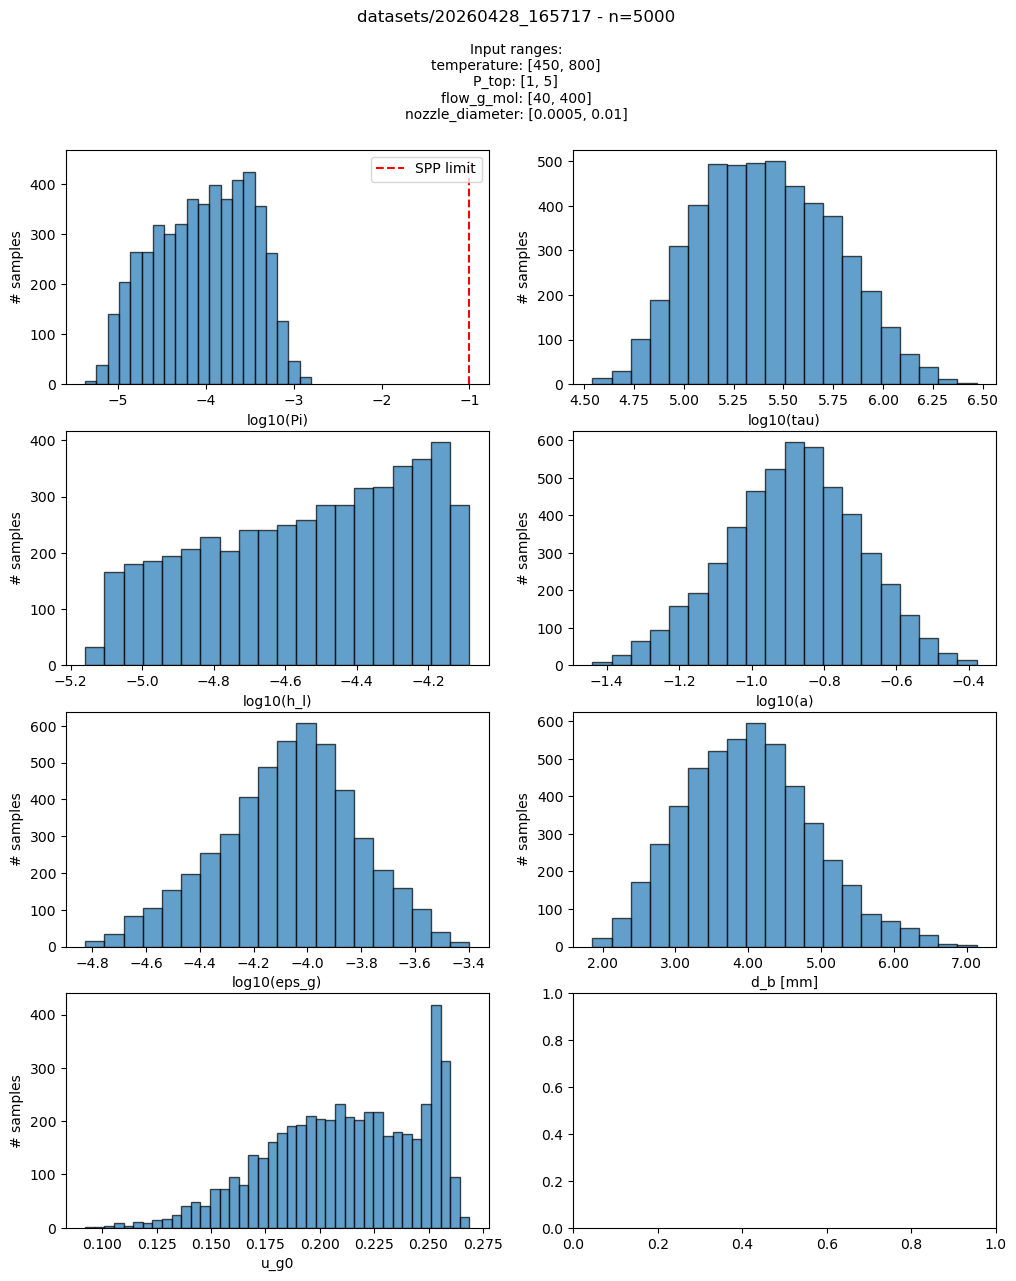

In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig,axs = plt.subplots(4,2, figsize=(12,14))
PP_data = pd.read_csv(FOLDER / "PP_data.csv")
plt.sca(axs[0,0])
plt.hist(np.log10(PP_data["Pi"].values), bins=20, edgecolor='black', alpha=0.7)
plt.vlines(np.log10(0.1), ymin=0, ymax=plt.gca().get_ylim()[1], colors="red", linestyles="dashed", label="SPP limit")
plt.xlabel("log10(Pi)")
plt.ylabel("# samples")
plt.legend()

axs[0,1].hist(np.log10(PP_data["tau"].values), bins=20, edgecolor='black', alpha=0.7)
axs[0,1].set_xlabel("log10(tau)")
axs[0,1].set_ylabel("# samples")

axs[1,0].hist(np.log10(PP_data["h_l"].values), bins=20, edgecolor='black', alpha=0.7)
axs[1,0].set_xlabel("log10(h_l)")
axs[1,0].set_ylabel("# samples")

axs[1,1].hist(np.log10(PP_data["a"].values), bins=20, edgecolor='black', alpha=0.7)
axs[1,1].set_xlabel("log10(a)")
axs[1,1].set_ylabel("# samples")

# axs[2,0].hist((PP_data["eps_g"].values), bins=20, edgecolor='black', alpha=0.7)
# axs[2,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*1e2:.3f}"))
# axs[2,0].set_xlabel("eps_g [%]")
axs[2,0].hist(np.log10(PP_data["eps_g"].values), bins=20, edgecolor='black', alpha=0.7)
axs[2,0].set_xlabel("log10(eps_g)")
axs[2,0].set_ylabel("# samples")

axs[2,1].hist((PP_data["d_b"].values), bins=20, edgecolor='black', alpha=0.7)
axs[2,1].set_xlabel("d_b [mm]")
axs[2,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x*1e3:.2f}"))
axs[2,1].set_ylabel("# samples")

axs[3,0].hist((PP_data["u_g0"].values), bins=40, edgecolor='black', alpha=0.7)
axs[3,0].set_xlabel("u_g0")
axs[3,0].set_ylabel("# samples")

fig.text(0.5,0.9,"Input ranges:\n" + "\n".join([f"{param}: [{problem['bounds'][i][0]}, {problem['bounds'][i][1]}]" for i, param in enumerate(problem["names"])]), fontsize=10, ha='center', va='bottom',)
plt.suptitle(f"{FOLDER} - n={len(PP_data)}")
plt.savefig(FOLDER / "postprocessing" / "distributions.png")
plt.show()

95% confidence interval for tau: [0.66  13.92] day


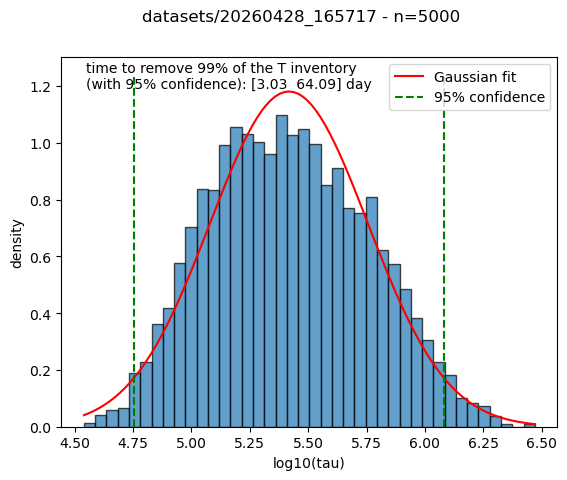

In [5]:
from scipy.stats import norm

log_tau = np.log10(PP_data["tau"].values)
plt.hist(log_tau, bins=40, edgecolor='black', alpha=0.7, density=True)
plt.xlabel("log10(tau)")
plt.ylabel("density")

# tau_mean = np.mean(log_tau)
# tau_std = np.std(log_tau)
log_tau_mean, log_tau_std = norm.fit(log_tau)
x = np.linspace(log_tau.min(), log_tau.max(), 100)

pdf = norm.pdf(x, log_tau_mean, log_tau_std)

# # equivalent 
# gaussian = (1/(log_tau_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - log_tau_mean) / log_tau_std) ** 2)
# np.allclose(pdf, gaussian)


plt.plot(x, pdf, color='red', label='Gaussian fit')

log_tau_95 = [log_tau_mean - 1.96*log_tau_std, log_tau_mean + 1.96*log_tau_std]

plt.vlines(log_tau_95, ymin=0, ymax=plt.gca().get_ylim()[1], colors="green", linestyles="dashed", label="95% confidence")
plt.legend()

tau_95 = np.power(10,log_tau_95) * ureg.s
annotation = f"time to remove 99% of the T inventory \n(with 95% confidence): {np.log(100) * tau_95.to('days'):<5.2f}"
plt.annotate(annotation, xy=(0.05, 0.99), xycoords='axes fraction', fontsize=10, verticalalignment='top')

plt.suptitle(f"{FOLDER} - n={len(PP_data)}")
plt.savefig(FOLDER / "postprocessing" / "tau_distribution_fitted.png")
print(f"95% confidence interval for tau: {tau_95.to('days'):<5.2f}")
plt.show()

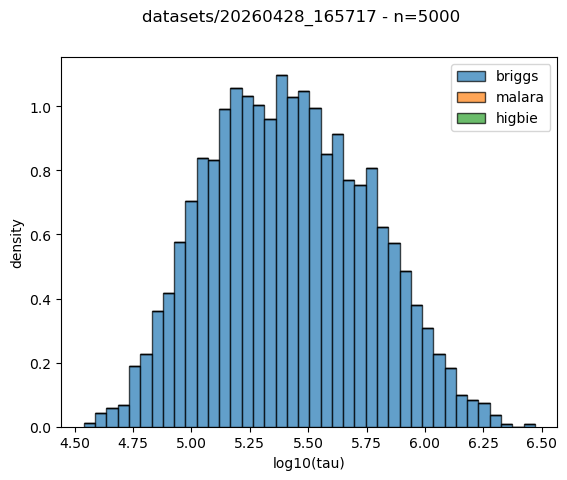

In [6]:
log_tau_malara = [log_tau[i] for i in range(len(log_tau)) if PP_data["h_l_corr"].values[i] == "h_l_malara"]
log_tau_higbie = [log_tau[i] for i in range(len(log_tau)) if PP_data["h_l_corr"].values[i] == "h_l_higbie"]
log_tau_briggs = [log_tau[i] for i in range(len(log_tau)) if PP_data["h_l_corr"].values[i] == "h_l_briggs"]

plt.hist([log_tau_briggs,log_tau_malara, log_tau_higbie], bins=40, edgecolor='black', alpha=0.7,
          density=True, label=["briggs","malara", "higbie", ], stacked=True)
plt.xlabel("log10(tau)")
plt.ylabel("density")

plt.legend()

plt.suptitle(f"{FOLDER} - n={len(PP_data)}")
plt.savefig(FOLDER / "postprocessing" / "tau_distribution_correlation.png")
plt.show()

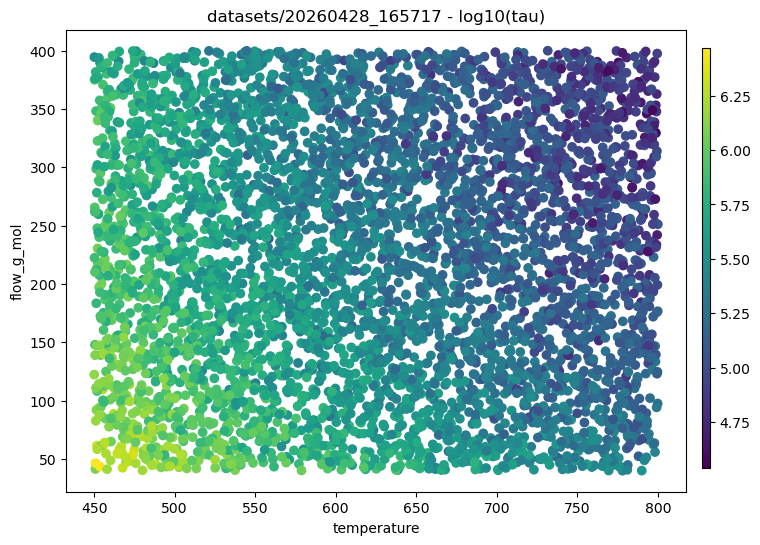

In [7]:

x_name = "temperature"
y_name = "flow_g_mol"
c_name = "tau"
Y_plot = np.log10(Y[c_name])

fig,axs = plt.subplots(1,1, figsize=(8,6))
plt.sca(axs)
plt.scatter(X[x_name], X[y_name], c=Y_plot, cmap="viridis", vmin=Y_plot.min(), vmax=Y_plot.max())

plt.title(f"{FOLDER} - log10({c_name})")

plt.xlabel(x_name)
plt.ylabel(y_name)
plt.colorbar(cax=fig.add_axes([0.92, 0.15, 0.01, 0.7]))

plt.savefig(FOLDER / "postprocessing" / "scatter.png")
plt.show()

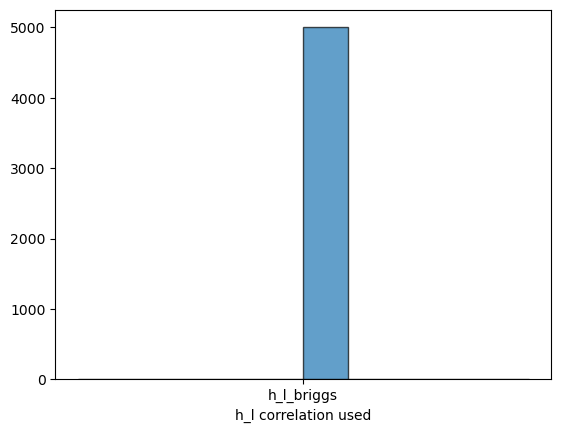

In [8]:
plt.hist(PP_data["h_l_corr"], edgecolor='black', alpha=0.7)
plt.xlabel("h_l correlation used")
plt.show()